# 🔍 Exploratory Data Analysis: Barcelona Amenities

This notebook walks through the complete EDA pipeline using OpenStreetMap data for Barcelona


### 🗾 Data Acquisition & Cleaning

**Goal:** Fetch raw OSM data for Barcelona, load it into a DataFrame, identify data quality issues, and produce a clean dataset.

---

### 1.1 Fetch Data with OSMnx

[OSMnx](https://osmnx.readthedocs.io/) is a Python package that lets you download and analyze OpenStreetMap data with a single function call. Under the hood it queries the Overpass API, but gives us a clean GeoDataFrame back — no manual HTTP requests needed.

**Key concept:** OSM data is contributed by volunteers — there is no schema enforcement. Tags are conventions, not standards.

In [120]:
import osmnx as ox
import os

# Fetch amenity features in Barcelona using OSMnx
# We limit to a curated set of amenity types to avoid overloading the API
# (fetching ALL amenities for a large city can return 15k–50k features)
PLACE_NAME = "Gràcia, Barcelona, Spain"
CITY_SLUG = "barcelona"
DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "data"))
RAW_DATA_PATH = os.path.join(DATA_DIR, f"{CITY_SLUG}_amenities_raw.gpkg")
CLEAN_DATA_PATH = os.path.join(DATA_DIR, f"clean_{CITY_SLUG}.csv")
os.makedirs(DATA_DIR, exist_ok=True)

AMENITY_TYPES = [
    "restaurant", "cafe", "fast_food", "bar", "pub",   # food & drink
    "pharmacy", "hospital", "clinic", "dentist",        # health
    "school", "university", "library", "kindergarten",  # education
    "bank", "atm", "post_office",                       # services
]

print(f"Fetching amenity data for {PLACE_NAME}...")
gdf = ox.features_from_place(PLACE_NAME, tags={"amenity": AMENITY_TYPES})

# Reset multi-index (element_type, osmid) to regular columns
gdf = gdf.reset_index()
gdf.to_file(RAW_DATA_PATH, driver="GPKG")

print(f"Fetched {len(gdf)} features")
print(f"Columns: {len(gdf.columns)}")
print(f"Geometry types:\n{gdf.geometry.geom_type.value_counts()}")
print(f"Saved raw OSM data to {RAW_DATA_PATH}")

Fetching amenity data for Gràcia, Barcelona, Spain...
Fetched 939 features
Columns: 196
Geometry types:
Point      892
Polygon     47
Name: count, dtype: int64
Saved raw OSM data to c:\Users\etmaglari\IAAC\edu.eda\data\barcelona_amenities_raw.gpkg


In [121]:
# Inspect one feature to understand the structure
gdf.iloc[0]

element                                                node
id                                                 82753755
geometry                       POINT (2.1585725 41.4025115)
addr:city                                         Barcelona
addr:full                          carrer Ramon I Cajal, 24
                                           ...             
panoramax:1                                             NaN
member_of                                               NaN
building:levels:underground                             NaN
fax                                                     NaN
type                                                    NaN
Name: 0, Length: 196, dtype: object

### What we see in a GeoDataFrame row

OSMnx returns a GeoDataFrame where:
- `element_type`: `"node"`, `"way"`, or `"relation"`
- `osmid`: unique OSM ID
- `geometry`: a Shapely geometry object (Point for nodes, Polygon for buildings, etc.)
- **All OSM tags are already flat columns** — no need to manually expand nested dicts

**Notice:** Unlike raw Overpass JSON where `tags` is a nested dictionary, OSMnx has already unpacked every tag into its own column. Most columns will be sparse (many NaN values) because not every feature has every tag.

### ⬇️ Load & Explore

Let's load the saved GeoDataFrame, extract coordinates, and get a regular DataFrame we can work with.

In [122]:
print(f"Raw OSM GeoPackage path: {RAW_DATA_PATH}")
print(f"Clean CSV path: {CLEAN_DATA_PATH}")

Raw OSM GeoPackage path: c:\Users\etmaglari\IAAC\edu.eda\data\barcelona_amenities_raw.gpkg
Clean CSV path: c:\Users\etmaglari\IAAC\edu.eda\data\clean_barcelona.csv


In [123]:
import pandas as pd
import geopandas as gpd


# Extract lat/lon from geometry centroids (works for both Points and Polygons)
gdf["lat"] = gdf.geometry.centroid.y
gdf["lon"] = gdf.geometry.centroid.x

# Convert to regular DataFrame for analysis
df = pd.DataFrame(gdf.drop(columns=["geometry"]))

# Rename osmid → id for consistency
if "osmid" in df.columns:
    df = df.rename(columns={"osmid": "id"})

# Drop osmnx metadata columns that aren't useful for analysis
for col in ["nodes", "ways"]:
    if col in df.columns:
        df = df.drop(columns=[col])

print(f"Total features: {len(df)}")
print(f"Columns: {len(df.columns)}")

Total features: 939
Columns: 197


C:\Users\etmaglari\AppData\Local\Temp\ipykernel_40988\3599857811.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["lat"] = gdf.geometry.centroid.y
C:\Users\etmaglari\AppData\Local\Temp\ipykernel_40988\3599857811.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["lon"] = gdf.geometry.centroid.x


In [124]:
# Shape and basic info
print(f"Shape: {df.shape}")
print(f"\nDtype summary:\n{df.dtypes.value_counts()}")
print(f"\nFirst 30 columns (alphabetized):")
print(sorted(df.columns.tolist())[:30])

Shape: (939, 197)

Dtype summary:
str        194
float64      2
int64        1
Name: count, dtype: int64

First 30 columns (alphabetized):
['access', 'addr:city', 'addr:floor', 'addr:full', 'addr:housename', 'addr:housenumber', 'addr:place', 'addr:postcode', 'addr:street', 'air_conditioning', 'alt_name', 'alt_name:ca', 'amenity', 'architect', 'atm', 'atm:network', 'atm:operator', 'bar', 'billiards', 'board_games', 'branch', 'brand', 'brand:ca', 'brand:es', 'brand:website', 'brand:wikidata', 'brand:wikipedia', 'brewery', 'building', 'building:levels']


In [125]:
df.head()

,element,id,addr:city,addr:full,addr:housenumber,addr:postcode,addr:street,amenity,check_date,contact:phone,...,panoramax,panoramax:0,architect,panoramax:1,member_of,building:levels:underground,fax,type,lat,lon
0,node,82753755,Barcelona,"carrer Ramon I Cajal, 24",24,08012,Carrer de Ramón y Cajal,pharmacy,2024-11-14,+34932135817,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.402512,2.158573
1,node,82781675,Barcelona,"carrer Verdi, 7",7,08012,Carrer de Verdi,pharmacy,2024-03-24,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.403115,2.157597
2,node,82781676,Barcelona,"carrer Asturies, 54",54,08012,Carrer d'Astúries,pharmacy,2023-11-10,+34932186196,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.403947,2.155336
3,node,430755048,Barcelona,NaN,252,08023,Avinguda de Vallcarca,pharmacy,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.419799,2.140857
4,node,430755135,Barcelona,"avinguda Vallcarca, 188",188,08023,Avinguda de Vallcarca,pharmacy,NaN,+34932843678,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.415487,2.142485


In [126]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 939 entries, 0 to 938
Columns: 197 entries, element to lon
dtypes: float64(2), int64(1), str(194)
memory usage: 1.5 MB


In [127]:
# OSMnx already expanded all tags into columns — no json_normalize needed!
# Let's see how many tag columns we have vs metadata columns
meta_cols = {"element_type", "id", "lat", "lon"}
tag_cols = sorted([c for c in df.columns if c not in meta_cols])
print(f"Tag columns found: {len(tag_cols)}")
print(f"\nFirst 30 tag columns (alphabetized):")
print(tag_cols[:30])

Tag columns found: 194

First 30 tag columns (alphabetized):
['access', 'addr:city', 'addr:floor', 'addr:full', 'addr:housename', 'addr:housenumber', 'addr:place', 'addr:postcode', 'addr:street', 'air_conditioning', 'alt_name', 'alt_name:ca', 'amenity', 'architect', 'atm', 'atm:network', 'atm:operator', 'bar', 'billiards', 'board_games', 'branch', 'brand', 'brand:ca', 'brand:es', 'brand:website', 'brand:wikidata', 'brand:wikipedia', 'brewery', 'building', 'building:levels']


In [128]:
# No merge step needed — OSMnx gives a flat table directly
# Let's verify the key columns are present
key_cols = ["id", "lat", "lon", "amenity", "name", "cuisine", "opening_hours"]
for col in key_cols:
    present = col in df.columns
    filled = df[col].notna().sum() if present else 0
    print(f"  {col}: {'✓' if present else '✗'}  ({filled} non-null)")

df.head()

  id: ✓  (939 non-null)
  lat: ✓  (939 non-null)
  lon: ✓  (939 non-null)
  amenity: ✓  (939 non-null)
  name: ✓  (897 non-null)
  cuisine: ✓  (281 non-null)
  opening_hours: ✓  (224 non-null)


,element,id,addr:city,addr:full,addr:housenumber,addr:postcode,addr:street,amenity,check_date,contact:phone,...,panoramax,panoramax:0,architect,panoramax:1,member_of,building:levels:underground,fax,type,lat,lon
0,node,82753755,Barcelona,"carrer Ramon I Cajal, 24",24,08012,Carrer de Ramón y Cajal,pharmacy,2024-11-14,+34932135817,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.402512,2.158573
1,node,82781675,Barcelona,"carrer Verdi, 7",7,08012,Carrer de Verdi,pharmacy,2024-03-24,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.403115,2.157597
2,node,82781676,Barcelona,"carrer Asturies, 54",54,08012,Carrer d'Astúries,pharmacy,2023-11-10,+34932186196,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.403947,2.155336
3,node,430755048,Barcelona,NaN,252,08023,Avinguda de Vallcarca,pharmacy,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.419799,2.140857
4,node,430755135,Barcelona,"avinguda Vallcarca, 188",188,08023,Avinguda de Vallcarca,pharmacy,NaN,+34932843678,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.415487,2.142485


In [129]:
# How complete is each column? (percentage of non-null values)
completeness = (df.notna().sum() / len(df) * 100).sort_values(ascending=False)
print("Column completeness (top 20):")
print(completeness.head(20).round(1).to_string())
print(f"\n... and {(completeness < 1).sum()} columns with <1% fill rate")

Column completeness (top 20):
element             100.0
id                  100.0
amenity             100.0
lon                 100.0
lat                 100.0
name                 95.5
addr:street          70.5
addr:housenumber     61.9
check_date           47.0
wheelchair           33.1
cuisine              29.9
addr:postcode        29.5
name:ca              25.9
addr:city            24.5
opening_hours        23.9
website              15.9
phone                15.8
ref                  13.1
outdoor_seating      12.6
source               10.5

... and 126 columns with <1% fill rate


### 🧙🏿‍♀️ Identify Issues

Let's document every data quality problem we can find. This is the core of EDA — understanding what's wrong before trying to fix it.

##### Issue checklist (what to look for):
- [ ] Wrong dtypes (are lat/lon actually floats?)
- [ ] Duplicates (same coordinates or same OSM id?)
- [ ] Missing values (which columns are sparse?)
- [ ] Inconsistent tagging (multiple formats for the same concept)
- [ ] Deprecated tags

In [130]:
# Issue 1: Check dtypes of lat/lon
print(f"lat dtype: {df['lat'].dtype}")
print(f"lon dtype: {df['lon'].dtype}")

# We extracted these from geometry, so they should be float64.
# But in some workflows (e.g. loading from CSV) they could arrive as strings.
print(f"\nSample lat values: {df['lat'].head().tolist()}")
print(f"Are they numeric? {pd.to_numeric(df['lat'], errors='coerce').notna().all()}")

lat dtype: float64
lon dtype: float64

Sample lat values: [41.4025115, 41.4031147, 41.4039465, 41.4197988, 41.4154874]
Are they numeric? True


In [131]:
# Issue 2: Duplicate nodes (same coordinates)
coord_dupes = df.duplicated(subset=["lat", "lon"], keep=False)
print(f"Nodes with duplicate coordinates: {coord_dupes.sum()}")

# Duplicate OSM IDs (shouldn't happen, but let's check)
id_dupes = df.duplicated(subset=["id"], keep=False)
print(f"Duplicate OSM IDs: {id_dupes.sum()}")

# Show some coordinate duplicates
if coord_dupes.any():
    print("\nExample duplicate coordinates:")
    dupes = df[coord_dupes].sort_values(["lat", "lon"]).head(10)
    print(dupes[["id", "lat", "lon", "amenity", "name"]].to_string())

Nodes with duplicate coordinates: 0
Duplicate OSM IDs: 0


In [132]:
# Issue 3: Amenity type distribution — how consistent is tagging?
print(f"Unique amenity values: {df['amenity'].nunique()}")
print(f"\nTop 20 amenity types:")
print(df["amenity"].value_counts().head(20).to_string())

Unique amenity values: 16

Top 20 amenity types:
amenity
restaurant      344
bar             131
cafe            131
pharmacy         85
fast_food        68
school           39
atm              29
bank             25
clinic           23
pub              17
dentist          16
kindergarten     12
hospital          8
post_office       6
library           4
university        1


In [133]:
# Issue 4: Cuisine tag chaos
cuisine_filled = df["cuisine"].dropna()
print(f"Nodes with cuisine tag: {len(cuisine_filled)} / {len(df)}")
print(f"\nSample cuisine values:")
print(cuisine_filled.sample(min(20, len(cuisine_filled)), random_state=42).tolist())

Nodes with cuisine tag: 281 / 939

Sample cuisine values:
['international', 'american;caribbean', 'regional', 'tapas', 'pizza', 'syrian', 'burger', 'regional;hot_dog;sandwich', 'sandwich', 'japanese', 'pizza', 'tapas', 'argentinian;pizza;sandwich;empanada', 'asian;japanese', 'tapas;burger', 'coffee_shop', 'tapas', 'lebanese', 'tapas', 'regional']


In [134]:
# Issue 5: Opening hours — how many formats?
if "opening_hours" in df.columns:
    oh = df["opening_hours"].dropna()
    print(f"Nodes with opening_hours: {len(oh)} / {len(df)}")
    print(f"\nSample opening_hours values (note the format variation):")
    print(oh.sample(min(15, len(oh)), random_state=42).tolist())
else:
    print("No 'opening_hours' column found")

Nodes with opening_hours: 224 / 939

Sample opening_hours values (note the format variation):
['Mo-Th 13:00-00:30; Fr-Sa 13:00-01:00; Su 13:00-00:30', 'Mo-Sa 09:30-20:30', 'We-Fr 17:00-21:00; Su 16:00-21:00', 'Mo-Fr 08:45-14:00, 16:30-20:30; Sa 08:45-14:00', 'Mo-Fr 08:00-20:30', 'Mo-Fr 07:30-20:00; Sa 08:30-13:00; Su 09:00-13:30', 'Tu-Sa 18:30-23:59', 'Tu-Fr 12:30-23:30; Sa 12:30-00:00', 'Mo-Fr 12:00-02:00; Sa-Su 11:00-02:00', 'Wed-Sun 13:00-16:00; 20:00-23:30', 'Mo-Fr 08:30-21:00; Sa 09:00-15:00', 'Tu-Th 12:00-23:30; Fr,Sa 12:00-00:30; Su 12:00-16:30', 'Mo-Fr 09:30-14:00, 17:30-22:00; Sa-Su 10:00-15:00', 'Mo-Fr 07:00-01:30, Sa 08:00-02:00, Su 16:00-01:00', 'Tu-Sa 19:00-23:00']


In [135]:
# Issue 6: Name columns — multilingual mess
name_cols = [c for c in df.columns if c.startswith("name")]
print(f"Name-related columns ({len(name_cols)}):")
for col in sorted(name_cols):
    filled = df[col].notna().sum()
    print(f"  {col}: {filled} values ({filled/len(df)*100:.1f}%)")

Name-related columns (11):
  name: 897 values (95.5%)
  name:2011-2016: 1 values (0.1%)
  name:ca: 243 values (25.9%)
  name:en: 16 values (1.7%)
  name:es: 44 values (4.7%)
  name:et: 1 values (0.1%)
  name:etymology:wikidata: 10 values (1.1%)
  name:fr: 1 values (0.1%)
  name:it: 2 values (0.2%)
  name:ko: 1 values (0.1%)
  name:ru: 2 values (0.2%)


### Summary of Issues Found

| # | Issue | Severity | Example |
|---|-------|----------|--------|
| 1 | Coordinate duplicates | Medium | Multiple nodes at exact same lat/lon |
| 2 | Sparse columns | Low | Most tag columns are >95% empty |
| 3 | Inconsistent `cuisine` | High | `italian;pizza` vs `Italian` vs `Pizza, Italian` |
| 4 | Opening hours formats | High | At least 5 different formats |
| 5 | Multilingual names | Medium | `name`, `name:en`, `name:sv` — which to use? |
| 6 | Missing values in key tags | Medium | Many restaurants have no `cuisine`, `phone`, etc. |

Now let's fix them.

### 🧹 Clean the Data

We'll build a cleaning pipeline step by step.

In [136]:
# Step 1: Ensure lat/lon are float
df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
df["lon"] = pd.to_numeric(df["lon"], errors="coerce")

# Drop rows where lat/lon couldn't be converted (if any)
before = len(df)
df = df.dropna(subset=["lat", "lon"])
print(f"Dropped {before - len(df)} rows with invalid coordinates")

Dropped 0 rows with invalid coordinates


In [137]:
# Step 2: Remove coordinate duplicates (keep first occurrence)
before = len(df)
df = df.drop_duplicates(subset=["lat", "lon"], keep="first")
print(f"Removed {before - len(df)} coordinate duplicates")
print(f"Remaining rows: {len(df)}")

Removed 0 coordinate duplicates
Remaining rows: 939


In [138]:
# Step 3: Drop columns with very low fill rates (< 1%)
# These add noise without insight
fill_rate = df.notna().sum() / len(df)
sparse_cols = fill_rate[fill_rate < 0.01].index.tolist()
print(f"Dropping {len(sparse_cols)} columns with <1% fill rate")

# But keep important columns even if sparse
keep_anyway = {"cuisine", "opening_hours", "phone", "website", "wheelchair"}
drop_cols = [c for c in sparse_cols if c not in keep_anyway]
df = df.drop(columns=drop_cols)

print(f"Shape after dropping sparse columns: {df.shape}")

Dropping 126 columns with <1% fill rate
Shape after dropping sparse columns: (939, 71)


In [139]:
# Step 4: Create a clean 'primary_name' column
# Priority: name > name:en > name:sv > first available name:* column
def get_primary_name(row):
    if pd.notna(row.get("name")):
        return row["name"]
    for col in ["name:en", "name:sv"]:
        if col in row.index and pd.notna(row.get(col)):
            return row[col]
    return None

df["primary_name"] = df.apply(get_primary_name, axis=1)
print(f"Nodes with a name: {df['primary_name'].notna().sum()} / {len(df)}")

Nodes with a name: 897 / 939


In [140]:
# Step 5: Select the columns we'll actually work with
core_cols = ["id", "lat", "lon", "amenity", "primary_name", "cuisine", "opening_hours"]

# Keep additional columns if they exist and have data
optional_cols = ["phone", "website", "wheelchair", "addr:street", "addr:housenumber"]
available_optional = [c for c in optional_cols if c in df.columns]

df_clean = df[core_cols + available_optional].copy()
print(f"Clean DataFrame shape: {df_clean.shape}")
df_clean.head(10)

Clean DataFrame shape: (939, 12)


,id,lat,lon,amenity,primary_name,cuisine,opening_hours,phone,website,wheelchair,addr:street,addr:housenumber
0,82753755,41.402512,2.158573,pharmacy,"Farmàcia Mauri Martínez, Emília",NaN,NaN,NaN,NaN,NaN,Carrer de Ramón y Cajal,24
1,82781675,41.403115,2.157597,pharmacy,"Farmàcia Valentines Nart, T - Gelabert Valentines",NaN,Mo-Fr 09:00-20:30; Sa 09:30-13:30,+34 932136301;+34 932133048,https://www.farmaciafedefarma.com/es/farmacia-...,no,Carrer de Verdi,7
2,82781676,41.403947,2.155336,pharmacy,Farmàcia del diamant,NaN,NaN,NaN,NaN,yes,Carrer d'Astúries,54
3,430755048,41.419799,2.140857,pharmacy,Farmacia J. Crespo Molina,NaN,"Mo,Sa 08:30-22:00",+34934180051,NaN,NaN,Avinguda de Vallcarca,252
4,430755135,41.415487,2.142485,pharmacy,Farmàcia Parc Virgili,NaN,NaN,NaN,NaN,yes,Avinguda de Vallcarca,188
5,570117144,41.402166,2.162341,restaurant,Cal Boter,regional,NaN,NaN,NaN,NaN,Carrer de Tordera,62
6,587998431,41.402044,2.162170,restaurant,Fonda Pepa,catalan,NaN,+34 93 207 22 53,https://www.fondapepa.com/,no,Carrer de Tordera,58
7,588002549,41.401893,2.161942,bar,La Cigale,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,588003295,41.401933,2.162054,restaurant,Sabes una Cosa,mexican,"Mo-Fr 20:00-23:30; Sa 13:30-15:30,20:00-23:30",NaN,https://linktr.ee/sabesunacosa,no,Carrer de Tordera,54
9,588012926,41.401926,2.161654,bar,La Fourmi,NaN,NaN,NaN,NaN,yes,Carrer de Milà i Fontanals,NaN


In [141]:
# Save cleaned data
df_clean.to_csv(CLEAN_DATA_PATH, index=False)
print(f"Saved to {CLEAN_DATA_PATH}")
print(f"\nFinal summary:")
print(f"  Rows: {len(df_clean)}")
print(f"  Columns: {len(df_clean.columns)}")
print(f"  Amenity types: {df_clean['amenity'].nunique()}")
print(f"  Named amenities: {df_clean['primary_name'].notna().sum()} ({df_clean['primary_name'].notna().mean()*100:.1f}%)")

Saved to c:\Users\etmaglari\IAAC\edu.eda\data\clean_barcelona.csv

Final summary:
  Rows: 939
  Columns: 12
  Amenity types: 16
  Named amenities: 897 (95.5%)



**What we accomplished:**
- Fetched ~15,000 amenity features using OSMnx (which queries Overpass under the hood)
- Loaded the GeoDataFrame, extracted lat/lon from geometry, and got a flat DataFrame
- Identified 6 data quality issues (duplicates, sparse columns, inconsistent tags, multilingual names)
- Built a cleaning pipeline: type conversion → dedup → drop sparse → extract primary name
- Saved a clean CSV ready for Day 2

**You should have by now:**
- Their own city's raw GeoPackage saved in `data/`
- A clean CSV with proper dtypes and no duplicates
- A documented list of issues they found in *their* city's data



## 🌆 Normalization, Visualization & Debugging

**Goal:** Normalize messy tags into analyzable columns, create publication-ready charts and interactive maps, and practice reading tracebacks.

## 🏷️ Normalize Tags

OSM tags are free-text fields. The same concept can be encoded in many different ways. Let's normalize the most important ones.

In [142]:
# Load the cleaned data from Day 1
df = pd.read_csv(CLEAN_DATA_PATH)
print(f"Loaded {len(df)} rows")
df.head()

Loaded 939 rows


,id,lat,lon,amenity,primary_name,cuisine,opening_hours,phone,website,wheelchair,addr:street,addr:housenumber
0,82753755,41.402512,2.158573,pharmacy,"Farmàcia Mauri Martínez, Emília",NaN,NaN,NaN,NaN,NaN,Carrer de Ramón y Cajal,24
1,82781675,41.403115,2.157597,pharmacy,"Farmàcia Valentines Nart, T - Gelabert Valentines",NaN,Mo-Fr 09:00-20:30; Sa 09:30-13:30,+34 932136301;+34 932133048,https://www.farmaciafedefarma.com/es/farmacia-...,no,Carrer de Verdi,7
2,82781676,41.403947,2.155336,pharmacy,Farmàcia del diamant,NaN,NaN,NaN,NaN,yes,Carrer d'Astúries,54
3,430755048,41.419799,2.140857,pharmacy,Farmacia J. Crespo Molina,NaN,"Mo,Sa 08:30-22:00",+34934180051,NaN,NaN,Avinguda de Vallcarca,252
4,430755135,41.415487,2.142485,pharmacy,Farmàcia Parc Virgili,NaN,NaN,NaN,NaN,yes,Avinguda de Vallcarca,188


### 🍜 Normalize `cuisine`

Problems to fix:
- Semicolon-separated values: `"italian;pizza"` → should be split
- Inconsistent casing: `"Italian"` vs `"italian"` vs `"ITALIAN"`
- Variant names: `"burger"` vs `"hamburger"`
- We'll extract the **primary cuisine** (first value) for analysis

In [143]:
# Before normalization — show the chaos
print("Raw cuisine values (sample):")
print(df["cuisine"].dropna().sample(min(50, df["cuisine"].notna().sum()), random_state=42).tolist())

Raw cuisine values (sample):
['international', 'american;caribbean', 'regional', 'tapas', 'pizza', 'syrian', 'burger', 'regional;hot_dog;sandwich', 'sandwich', 'japanese', 'pizza', 'tapas', 'argentinian;pizza;sandwich;empanada', 'asian;japanese', 'tapas;burger', 'coffee_shop', 'tapas', 'lebanese', 'tapas', 'regional', 'pizza', 'pizza', 'ice_cream', 'japanese;ramen', 'sushi', 'spanish;tapas;burger', 'burger;beer;street_food', 'burger', 'pizza', 'pizza', 'pizza', 'japanese;dumpling', 'italian', 'coffee_shop', 'lebanese;fenician', 'japanese', 'ethiopian', 'japanese', 'burger', 'local', 'kebab;turkish', 'bakery', 'mexican', 'chinese', 'chicken', 'italian', 'burger', 'japanese', 'pizza;cuban', 'coffee_shop;italian;pizza']


In [144]:
def normalize_cuisine(value):
    """Extract and normalize the primary cuisine from an OSM cuisine tag."""
    if pd.isna(value):
        return None
    
    # Split on semicolons (OSM convention) and commas
    parts = str(value).replace(",", ";").split(";")
    primary = parts[0].strip().lower()
    
    # Merge common variants
    variants = {
        "burger": "hamburger",
        "sushi": "japanese",
        "kebab": "kebab",
        "döner": "kebab",
        "doner": "kebab",
        "falafel": "middle_eastern",
        "sandwich": "sandwich",
        "sub": "sandwich",
    }
    primary = variants.get(primary, primary)
    
    # Title case for clean output
    return primary.replace("_", " ").title()

df["cuisine_clean"] = df["cuisine"].apply(normalize_cuisine)

print("After normalization — top 15 cuisines:")
print(df["cuisine_clean"].value_counts().head(15).to_string())

After normalization — top 15 cuisines:
cuisine_clean
Japanese         31
Regional         28
Pizza            26
Tapas            23
Coffee Shop      18
Hamburger        15
Spanish          10
Sandwich          9
Mexican           8
Italian           8
Kebab             8
Mediterranean     6
Chinese           6
Asian             5
Indian            5


### ⌛ Parse `opening_hours`

Opening hours in OSM are notoriously varied. Instead of a full parser, we'll classify each value:
- **Has hours**: parseable format (we won't parse fully — that's a project in itself)
- **24/7**: always open
- **Missing**: no data
- **Unparseable**: weird format we can't handle

In [145]:
def classify_opening_hours(value):
    """Classify an opening_hours value into a simple category."""
    if pd.isna(value):
        return "missing"
    
    v = str(value).strip().lower()
    
    if v == "24/7":
        return "24/7"
    elif any(day in v for day in ["mo", "tu", "we", "th", "fr", "sa", "su",
                                   "monday", "tuesday", "wednesday",
                                   "thursday", "friday", "saturday", "sunday"]):
        return "has_hours"
    elif ":" in v and any(c.isdigit() for c in v):
        return "has_hours"  # Probably a time format like "08:00-17:00"
    else:
        return "unparseable"

df["hours_status"] = df["opening_hours"].apply(classify_opening_hours)

print("Opening hours classification:")
print(df["hours_status"].value_counts().to_string())
print(f"\nExamples of 'unparseable':")
unparseable = df[df["hours_status"] == "unparseable"]["opening_hours"]
if len(unparseable) > 0:
    print(unparseable.head(10).tolist())

Opening hours classification:
hours_status
missing      715
has_hours    216
24/7           8

Examples of 'unparseable':


### 🌇 Visualize with matplotlib

Static charts are good for reports, papers, presentations. Let's answer some questions about Barcelona's amenities.

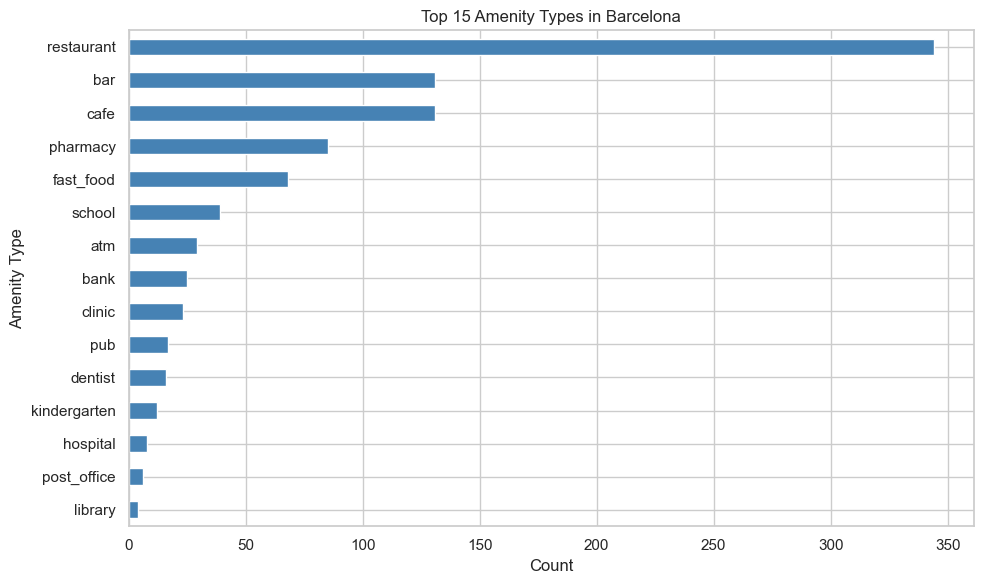

In [ ]:
import matplotlib.pyplot as plt

# Chart 1: Top 15 amenity types
top_amenities = df["amenity"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top_amenities.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Count")
ax.set_ylabel("Amenity Type")
ax.set_title("Top 15 Amenity Types in Barcelona")
ax.invert_yaxis()  # Largest at top
plt.tight_layout()
plt.show()
#visualization code for top amenities in Barcelona

C:\Users\etmaglari\AppData\Local\Temp\ipykernel_40988\1047985568.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_top, y="cuisine_clean", order=top_15, palette="flare", ax=ax)


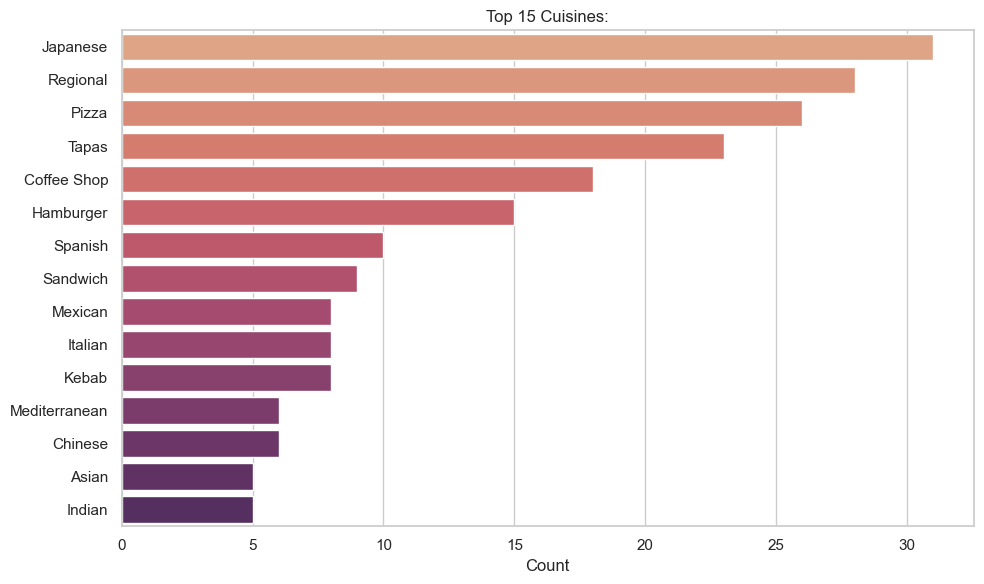

In [ ]:
##Group 3 - Seaborn NEW CHART
import seaborn as sns


sns.set_theme(style="whitegrid")

# Chart 1 (seaborn): Top 15 amenity types
# With matplotlib we had to manually create a barh + set labels.
# Seaborn's countplot handles counting and orientation in one call.

top_15 = df["cuisine_clean"].value_counts().head(15).index
df_top = df[df["cuisine_clean"].isin(top_15)]

fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(data=df_top, y="cuisine_clean", order=top_15, palette="flare", ax=ax)
ax.set_title("Top 15 Cuisines:")
ax.set_xlabel("Count")
ax.set_ylabel ("")
plt.tight_layout()
plt.show()

C:\Users\etmaglari\AppData\Local\Temp\ipykernel_40988\1407038491.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


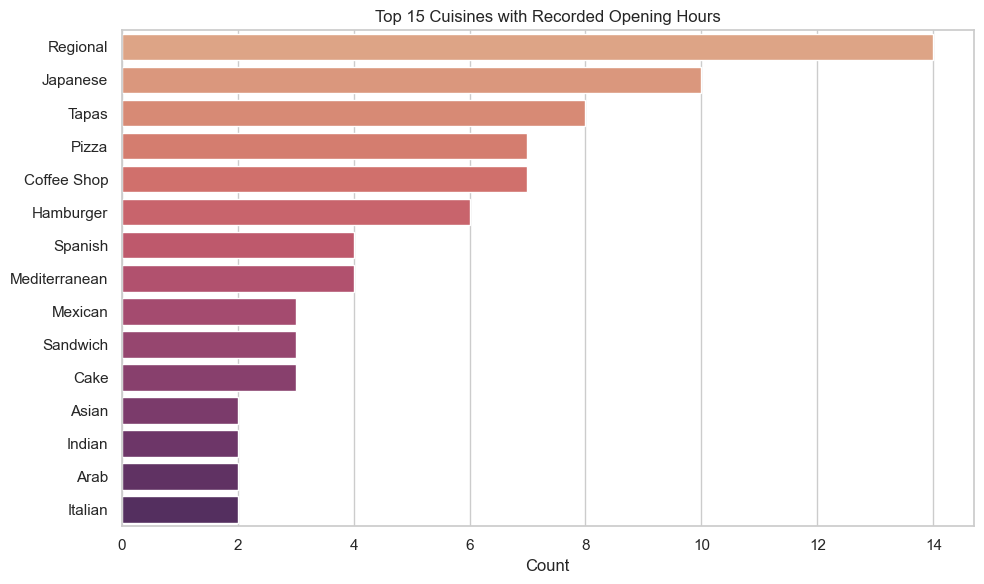

In [168]:
##Group 3 NEW CHART 2
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

filtered = df[
    df["hours_status"].isin(["has_hours", "24/7"]) &
    df["cuisine_clean"].notna()
].copy()

top_15 = filtered["cuisine_clean"].value_counts().head(15).index
df_top = filtered[filtered["cuisine_clean"].isin(top_15)]

fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(
    data=df_top,
    y="cuisine_clean",
    order=top_15,
    palette="flare",
    ax=ax
)

ax.set_title("Top 15 Cuisines with Recorded Opening Hours")
ax.set_xlabel("Count")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

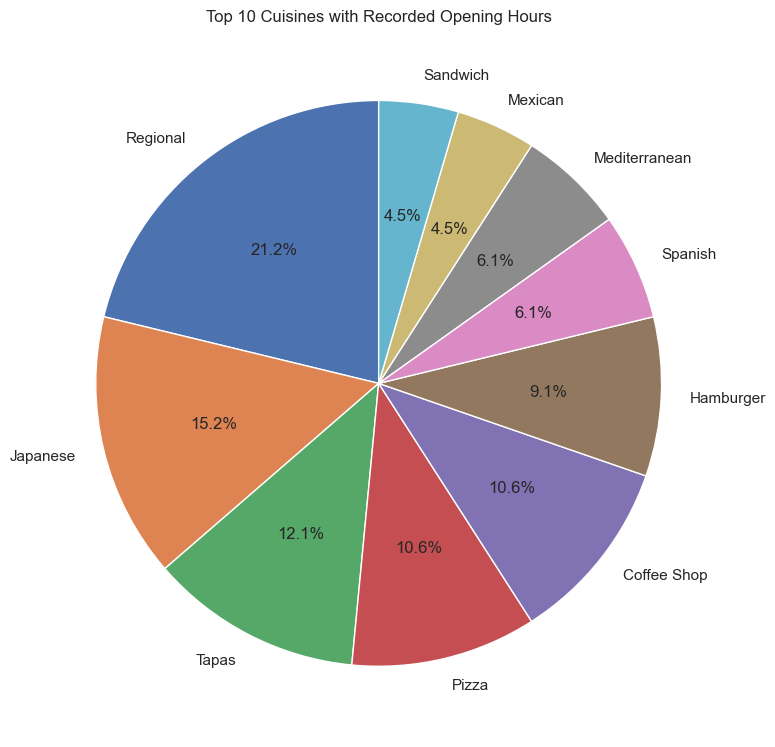

In [169]:
##Group 3 - Seaborn NEW CHART 3
import matplotlib.pyplot as plt

filtered = df[
    df["hours_status"].isin(["has_hours", "24/7"]) &
    df["cuisine_clean"].notna()
].copy()

top_cuisines = filtered["cuisine_clean"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(
    top_cuisines.values,
    labels=top_cuisines.index,
    autopct="%1.1f%%",
    startangle=90
)
ax.set_title("Top 10 Cuisines with Recorded Opening Hours")
plt.tight_layout()
plt.show()

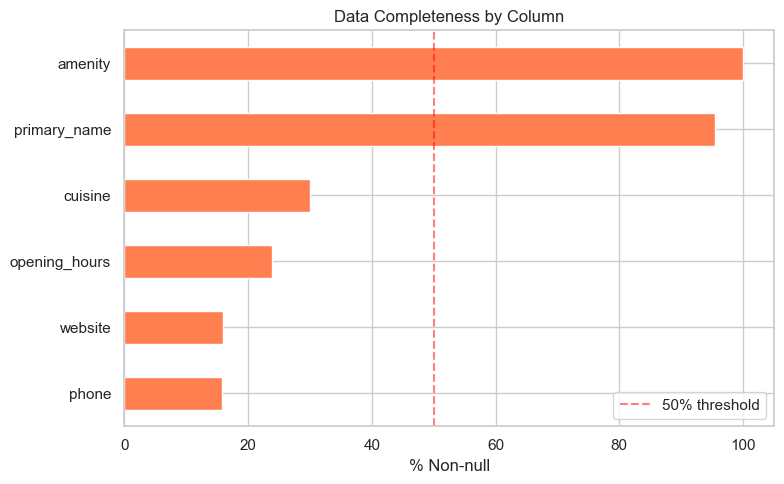

In [158]:
# Chart 2: Data completeness per column
completeness = df[["amenity", "primary_name", "cuisine", "opening_hours",
                    "phone", "website"]].notna().mean() * 100

fig, ax = plt.subplots(figsize=(8, 5))
completeness.sort_values().plot(kind="barh", ax=ax, color="coral")
ax.set_xlabel("% Non-null")
ax.set_title("Data Completeness by Column")
ax.axvline(x=50, color="red", linestyle="--", alpha=0.5, label="50% threshold")
ax.legend()
plt.tight_layout()
plt.show()

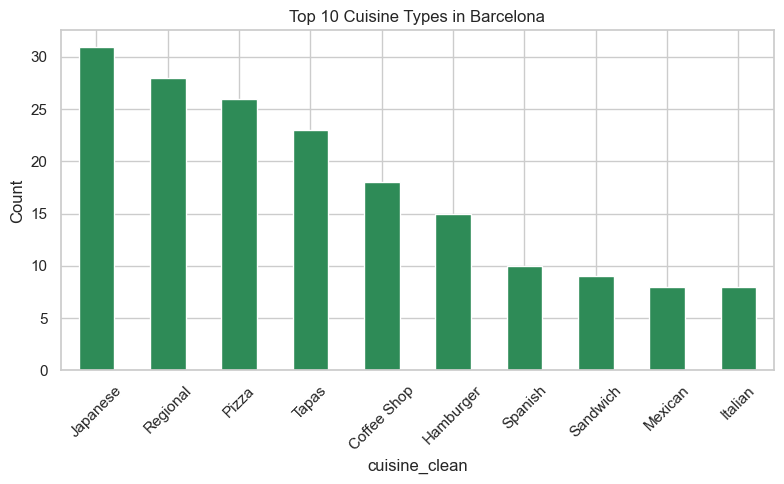

In [148]:
# Chart 3: Cuisine distribution (for nodes that have cuisine data)
top_cuisines = df["cuisine_clean"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(8, 5))
top_cuisines.plot(kind="bar", ax=ax, color="seagreen")
ax.set_ylabel("Count")
ax.set_title("Top 10 Cuisine Types in Barcelona")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### 🎨 Same charts with seaborn

Seaborn wraps matplotlib with better defaults: automatic themes, built-in color palettes, and statistical awareness. Below we recreate the same three charts — notice how much less boilerplate is needed.

C:\Users\etmaglari\AppData\Local\Temp\ipykernel_40988\3147298765.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_top, y="amenity", order=top_15, palette="Blues_d", ax=ax)


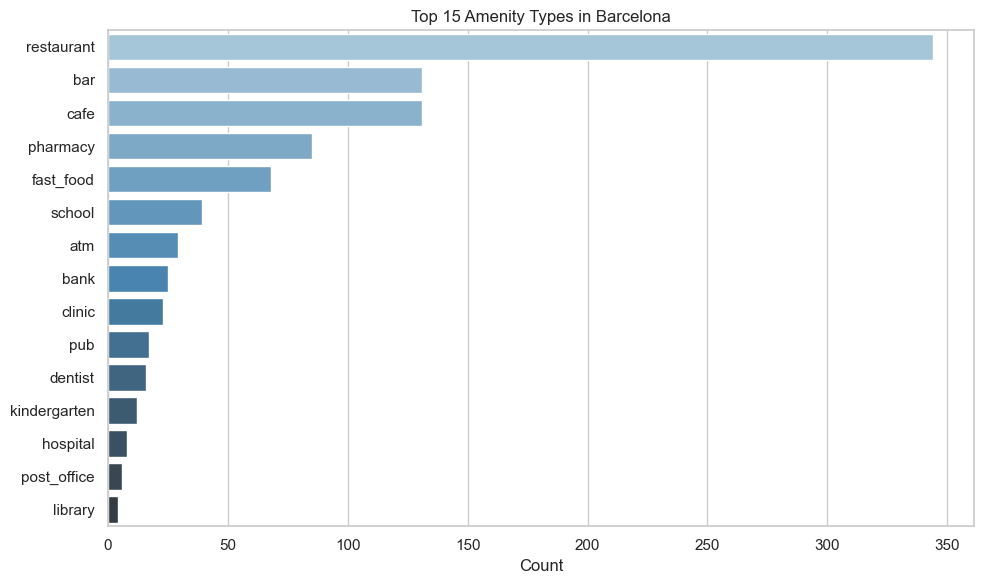

In [149]:
import seaborn as sns

sns.set_theme(style="whitegrid")

# Chart 1 (seaborn): Top 15 amenity types
# With matplotlib we had to manually create a barh + set labels.
# Seaborn's countplot handles counting and orientation in one call.

top_15 = df["amenity"].value_counts().head(15).index
df_top = df[df["amenity"].isin(top_15)]

fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(data=df_top, y="amenity", order=top_15, palette="Blues_d", ax=ax)
ax.set_title("Top 15 Amenity Types in Barcelona")
ax.set_xlabel("Count")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

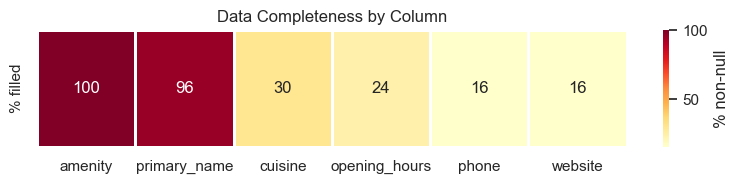

In [150]:
# Chart 2 (seaborn): Data completeness — a heatmap instead of a bar chart
# This shows how seaborn encourages different chart choices for the same question.

cols_to_check = ["amenity", "primary_name", "cuisine", "opening_hours", "phone", "website"]
completeness_df = df[cols_to_check].notna().mean().to_frame(name="% filled").T * 100

fig, ax = plt.subplots(figsize=(8, 2))
sns.heatmap(completeness_df, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=1, cbar_kws={"label": "% non-null"}, ax=ax)
ax.set_title("Data Completeness by Column")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

C:\Users\etmaglari\AppData\Local\Temp\ipykernel_40988\4172791051.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cuisines.values, y=top_cuisines.index, palette="Greens_d", ax=ax)


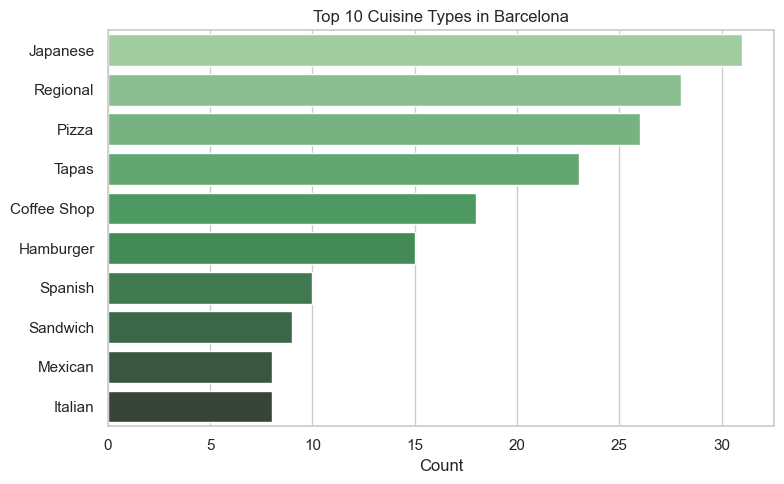

In [151]:
# Chart 3 (seaborn): Cuisine distribution
# barplot() takes pre-computed values — compare with the manual .plot(kind="bar") above.

top_cuisines = df["cuisine_clean"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index, palette="Greens_d", ax=ax)
ax.set_xlabel("Count")
ax.set_ylabel("")
ax.set_title("Top 10 Cuisine Types in Barcelona")
plt.tight_layout()
plt.show()

### matplotlib vs seaborn — when to use which?

| | matplotlib | seaborn |
|---|-----------|---------|
| **Control** | Full control over every element | Opinionated defaults — less knobs to turn |
| **Aesthetics** | Plain out of the box, needs styling | Polished by default (themes, palettes) |
| **Statistical** | No built-in stats | Built-in aggregation, confidence intervals, distributions |
| **Best for** | Custom/unusual charts, fine-tuning publication figures | Quick exploration, statistical summaries, heatmaps |
| **Under the hood** | The engine | A wrapper around matplotlib — you can mix both |

**Rule of thumb:** Start with seaborn for fast exploration, switch to matplotlib when you need pixel-level control.

## 2.3 Visualize with plotly (Interactive Maps)

The killer feature of geographic data — you can see it on a map. Plotly gives us interactive, zoomable maps.

In [152]:
import plotly.express as px

# Map 1: All amenities, colored by type (top 10 types, rest grouped as "other")
top_types = df["amenity"].value_counts().head(10).index.tolist()
df["amenity_group"] = df["amenity"].apply(lambda x: x if x in top_types else "other")

fig = px.scatter_mapbox(
    df,
    lat="lat",
    lon="lon",
    color="amenity_group",
    hover_name="primary_name",
    hover_data=["amenity", "cuisine_clean", "hours_status"],
    title="Barcelona Amenities",
    mapbox_style="carto-positron",
    zoom=11,
    height=600,
    opacity=0.7,
)
fig.update_layout(margin={"r": 0, "t": 40, "l": 0, "b": 0})
fig.show()

C:\Users\etmaglari\AppData\Local\Temp\ipykernel_40988\2233359210.py:7: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


In [153]:
# Map 2: Just restaurants, colored by cuisine
restaurants = df[df["amenity"].isin(["restaurant", "cafe", "fast_food"])].copy()
restaurants["cuisine_display"] = restaurants["cuisine_clean"].fillna("Unknown")

fig = px.scatter_mapbox(
    restaurants,
    lat="lat",
    lon="lon",
    color="cuisine_display",
    hover_name="primary_name",
    hover_data=["amenity", "opening_hours"],
    title="Restaurants, Cafés & Fast Food in Barcelona (colored by cuisine)",
    mapbox_style="carto-positron",
    zoom=12,
    height=600,
    opacity=0.7,
)
fig.update_layout(margin={"r": 0, "t": 40, "l": 0, "b": 0})
fig.show()

C:\Users\etmaglari\AppData\Local\Temp\ipykernel_40988\828881172.py:5: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


### 🪲 Debugging

Let's walk through some common errors that happen during EDA. These are **intentionally broken** — the goal is to practice reading tracebacks and diagnosing problems.

In [154]:
# 🐛 Bug 1: KeyError — common when column names have subtle differences
# Run this cell — it will crash. Read the traceback.

# This WILL raise a KeyError:
# df["Amenity"].value_counts()  # <-- capital A!

# Uncomment above to demo, then fix:
print("Fix: column names are case-sensitive in pandas")
print(f"Available columns containing 'amen': {[c for c in df.columns if 'amen' in c.lower()]}")
df["amenity"].value_counts().head()

Fix: column names are case-sensitive in pandas
Available columns containing 'amen': ['amenity', 'amenity_group']


amenity
restaurant    344
bar           131
cafe          131
pharmacy       85
fast_food      68
Name: count, dtype: int64

In [155]:
# 🐛 Bug 2: Merge explosion — a many-to-many merge that blows up the row count

# Create two small DataFrames that share a non-unique key
left = pd.DataFrame({"amenity": ["restaurant", "cafe", "restaurant"], "score": [4, 5, 3]})
right = pd.DataFrame({"amenity": ["restaurant", "restaurant", "cafe"], "rating": ["A", "B", "A"]})

print(f"Left rows: {len(left)}, Right rows: {len(right)}")
print("Left:\n", left)
print("\n----\n")
print("Right:\n", right)


Left rows: 3, Right rows: 3
Left:
       amenity  score
0  restaurant      4
1        cafe      5
2  restaurant      3

----

Right:
       amenity rating
0  restaurant      A
1  restaurant      B
2        cafe      A


In [156]:
# This merge will EXPLODE — 2 restaurants × 2 restaurants = 4 matches for restaurant alone
merged = left.merge(right, on="amenity")
print(f"Merged rows: {len(merged)}  ← MORE than either input!")
print("\nThis is a many-to-many merge. Every matching row on the left")
print("gets paired with every matching row on the right.")
merged

Merged rows: 5  ← MORE than either input!

This is a many-to-many merge. Every matching row on the left
gets paired with every matching row on the right.


,amenity,score,rating
0,restaurant,4,A
1,restaurant,4,B
2,cafe,5,A
3,restaurant,3,A
4,restaurant,3,B


In [157]:
# 🐛 Bug 3: Silent dtype coercion — mixing int and NaN forces float64

# Simulate building:levels data (some are int, some are missing)
levels_data = pd.DataFrame({
    "building": ["A", "B", "C", "D", "E"],
    "levels": [3, 5, None, 2, None]
})

print(f"dtype of levels: {levels_data['levels'].dtype}")
print("Expected int, got float64! NaN forces the whole column to float.")
print(f"\nValues: {levels_data['levels'].tolist()}")
print("Notice: 3.0 instead of 3, 5.0 instead of 5")

# Fix: use nullable integer type
levels_data["levels_fixed"] = levels_data["levels"].astype("Int64")
print(f"\nFixed dtype: {levels_data['levels_fixed'].dtype}")
print(f"Fixed values: {levels_data['levels_fixed'].tolist()}")

dtype of levels: float64
Expected int, got float64! NaN forces the whole column to float.

Values: [3.0, 5.0, nan, 2.0, nan]
Notice: 3.0 instead of 3, 5.0 instead of 5

Fixed dtype: Int64
Fixed values: [3, 5, <NA>, 2, <NA>]


**What we accomplished:**
- Normalized `cuisine` tags (semicolons, casing, variants)
- Classified `opening_hours` into simple categories
- Created matplotlib bar charts (amenity distribution, data completeness, cuisines)
- Created interactive plotly maps (all amenities + restaurant/cuisine map)
- Walked through 3 common debugging scenarios

**You should have by now:**
- Normalized tags for their city
- At least 2 matplotlib charts
- At least 1 interactive plotly map
- Completed the debugging exercise (Exercise 05)

## 💄 Streamlit & Deployment
**Goal:** Convert notebook code into a Streamlit app and deploy it as a live web app.

### 🍫 From Notebook to App

A Jupyter notebook is an **exploration tool** — you run cells one by one, go back, try things, make mistakes.

A Streamlit app is a **production artifact** — it's a `.py` file that runs top to bottom, every time someone visits the URL.

**Key differences:**

| Notebook | Streamlit app |
|----------|---------------|
| Cell-by-cell execution | Runs top to bottom on every interaction |
| `print()` for output | `st.write()`, `st.metric()`, `st.plotly_chart()` |
| Variables persist in kernel memory | Use `@st.cache_data` to avoid re-fetching data |
| Inline plots with `plt.show()` | `st.pyplot(fig)` or `st.plotly_chart(fig)` |
| No user interaction | Widgets: `st.selectbox()`, `st.slider()`, `st.text_input()` |



### 🚶🏿‍♀️‍➡️ Streamlit Walkthrough

Open [`app_stockholm.py`](app_stockholm.py) in this directory — it's a complete reference app that does everything we did in this notebook, but as a Streamlit web app.

**Run it locally:**

```bash
cd example/
streamlit run app_stockholm.py
```

**Structure of `app_stockholm.py`:**

1. **Page config** — `st.set_page_config(page_title=..., layout="wide")`
2. **Data loading** — `@st.cache_data` function that reads CSV (or fetches from API)
3. **Sidebar** — filters (amenity type dropdown, show/hide options)
4. **Main area** — title, KPI metrics row, map, charts

**Key pattern: `@st.cache_data`**

Without caching, Streamlit re-runs the entire script every time the user clicks anything. `@st.cache_data` stores the result of a function and only re-runs it if the inputs change.

```python
@st.cache_data
def load_data():
    df = pd.read_csv("data/clean_barcelona.csv")  # only runs once!
    return df
```

### 📦 Deploy

Follow the step-by-step guide in [`docs/deploy.md`](../docs/deploy.md).

**Quick summary:**
1. Push your completed `app.py` to your GitHub fork
2. Go to [share.streamlit.io](https://share.streamlit.io)
3. Connect your repo, set `app.py` as the main file
4. Click Deploy
5. Get your public URL — that's your portfolio piece

**Live demo:** (teacher deploys `app_stockholm.py` in front of the class)


**What we accomplished:**
- Understood the difference between exploration code (notebooks) and production code (`.py`)
- Built a Streamlit app with filters, maps, charts, and KPI metrics
- Deployed to Streamlit Community Cloud
- Each student has a **public URL** to a live data app — a real portfolio piece

**You leave with:**
1. A GitHub repo with cleaned data and analysis notebooks
2. A deployed Streamlit app with a public URL
3. Experience with pandas, matplotlib, plotly, and Streamlit
4. The ability to read tracebacks and debug data issues
5. Understanding of real-world data quality problems


**Mapping notebook cells to app.py sections:**

```
Notebook                          →  app.py
────────────────────────────────────────────────────────
import pandas, plotly             →  import pandas, plotly, streamlit
pd.read_csv("data/clean.csv")     →  @st.cache_data def load_data(): ...
df["amenity"].value_counts()      →  st.bar_chart() or st.plotly_chart()
px.scatter_mapbox(df, ...)        →  fig = px.scatter_mapbox(...); st.plotly_chart(fig)
(no equivalent)                   →  st.sidebar.selectbox("Filter by type", ...)
print(f"Total: {len(df)}")        →  st.metric("Total Amenities", len(df))
```